In [1]:
# ============================================================
# Notebook setup
# ============================================================

%load_ext autoreload
%autoreload 2

# Control figure size
figsize=(14, 4)

from util import util
import os
import pandas as pd
import numpy as np

# Load data
data_file = os.path.join('..', 'data', 'er.csv')
#data = util.load_ed_data(data_file)

# Emergency Deparment Management Problems

## Emergency Room @ Maggiore Hospital

**We will now consider a problem from the healthcare sector**

We will use a dataset for the "Maggiore" hospital in Bologna

<center><img src="assets/maggiore.jpg" width="65%"/></center>

* In particular, we will focus on predicting arrivals
* ...To the Emergency Department (Pronto Soccorso)

## A Look at the Dataset

**We will start as usual by having a look at the dataset**

In [ ]:
data = util.load_ed_data(data_file)
data

,year,ID,Triage,TkCharge,Code,Outcome
0,2018,1,2018-01-01 00:17:33,2018-01-01 04:15:36,green,admitted
1,2018,2,2018-01-01 00:20:33,2018-01-01 03:14:19,green,admitted
2,2018,3,2018-01-01 00:47:59,2018-01-01 04:32:30,white,admitted
51238,2018,51239,2018-01-01 00:49:51,NaT,white,abandoned
51240,2018,51241,2018-01-01 01:00:40,NaT,green,abandoned
...,...,...,...,...,...,...
95665,2019,95666,2019-10-31 23:26:54,2019-10-31 23:41:13,yellow,admitted
95666,2019,95667,2019-10-31 23:46:43,2019-11-01 09:30:25,green,admitted
108622,2019,108623,2019-10-31 23:54:05,NaT,green,abandoned
95667,2019,95668,2019-10-31 23:55:32,2019-11-01 00:18:46,yellow,admitted


## A Look at the Dataset

In [3]:
data.iloc[:3]

,year,ID,Triage,TkCharge,Code,Outcome
0,2018,1,2018-01-01 00:17:33,2018-01-01 04:15:36,green,admitted
1,2018,2,2018-01-01 00:20:33,2018-01-01 03:14:19,green,admitted
2,2018,3,2018-01-01 00:47:59,2018-01-01 04:32:30,white,admitted


* Each row refers to a single patient
* `Triage` is the arrival time of each patient
* `TKCharge` is the time when a patient starts the first visit
* `Code` refers to the estimated priority (white < green < yellow < red)
* `Outcome` discriminates some special conditions (people quitting, fast tracks)

## A Look at the Dataset

**Let's also have a look at the data types**

In [4]:
data.dtypes

year                 int64
ID                   int64
Triage      datetime64[ns]
TkCharge    datetime64[ns]
Code              category
Outcome           category
dtype: object

**As we said, we will focus for on _predicting arrivals_**

...Hence, it makes sense to sort rows by increasing triage time:

In [5]:
data.sort_values(by='Triage', inplace=True)

## Inter-Arrival Times

**Let's check empirically the distribution of the inter-arrival times**

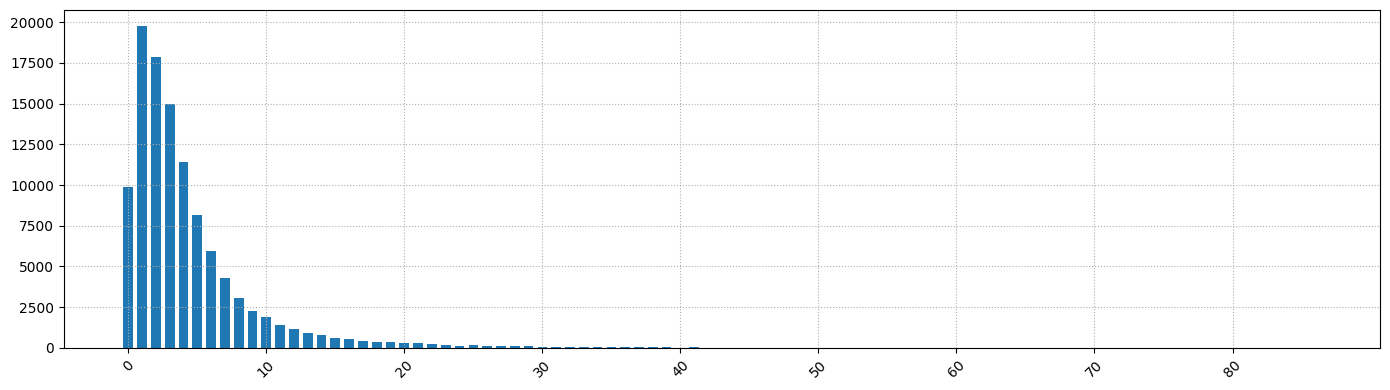

In [ ]:
delta = data['Triage'].iloc[1:].dt.round('2min') - data['Triage'].iloc[:-1].dt.round('2min').values
tmp = delta.value_counts().sort_index().values
tmp = pd.Series(index=np.arange(len(tmp)), data=tmp)
util.plot_bars(tmp, tick_gap=10, figsize=figsize)

#inter-arrival times means the time between consecutive arrivals of patients to the emergency department.
#on the x axis we have the inter-arrival times in minutes (2 min intervals) and on the y axis we have the frequency of those inter-arrival times.

* There is a number of very low inter-arrival times
* This is due to how triage is performed (bursts, rather than a steady flow)

## Waiting Time

**Here is the distribution of the waiting times**

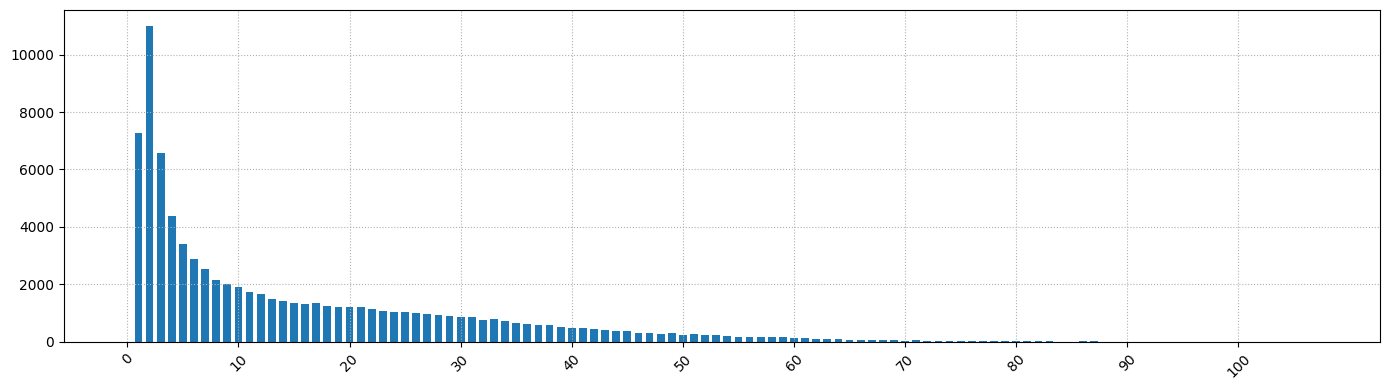

In [ ]:
tmp = data[~data['TkCharge'].isnull()]
wait_time = tmp['TkCharge'].dt.round('10min') - tmp['Triage'].dt.round('10min') #the way we calculate wait time is by subtracting the triage time from the tkcharge time.
# we round to 10 min intervals to make the plot more readable. so we will have wait times like 0 min, 10 min, 20 min, etc.
tmp = wait_time.value_counts().sort_index().values
tmp = pd.Series(index=np.arange(len(tmp)), data=tmp)
util.plot_bars(tmp, tick_gap=10, figsize=figsize)

#wait times means the time patients spend waiting from triage to being treated.
# on the x axis we have the wait times in minutes and on the y axis we have the frequency of those wait times.

#The bar at x=1 does not represent 1 minute. It represents the 1st 10-minute interval (i.e., 10 minutes).
#The bar at x=2 represents the 2nd 10-minute interval (i.e., 20 minutes).
#The tick mark at x=10 represents the 10th interval (i.e., 100 minutes).

* The distritbution is _heavy-tailed_
* I.e. the probability of very long waiting times (even 15 hours) is non-negligible

## Code Distribution

**The distribution of the priority codes**

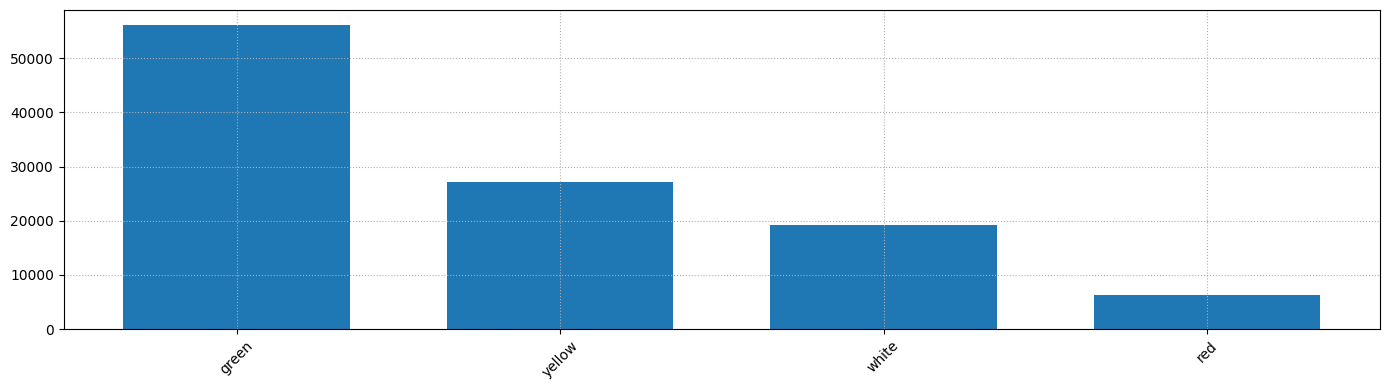

In [8]:
util.plot_bars(data['Code'].value_counts(), figsize=figsize)

* Green code (low severity) form the majority of arrivals
* Yellow and red codes (mid and high severity) are in smaller numbers
* White codes (lowest priority) are also not very frequent

## Outcome Distribution

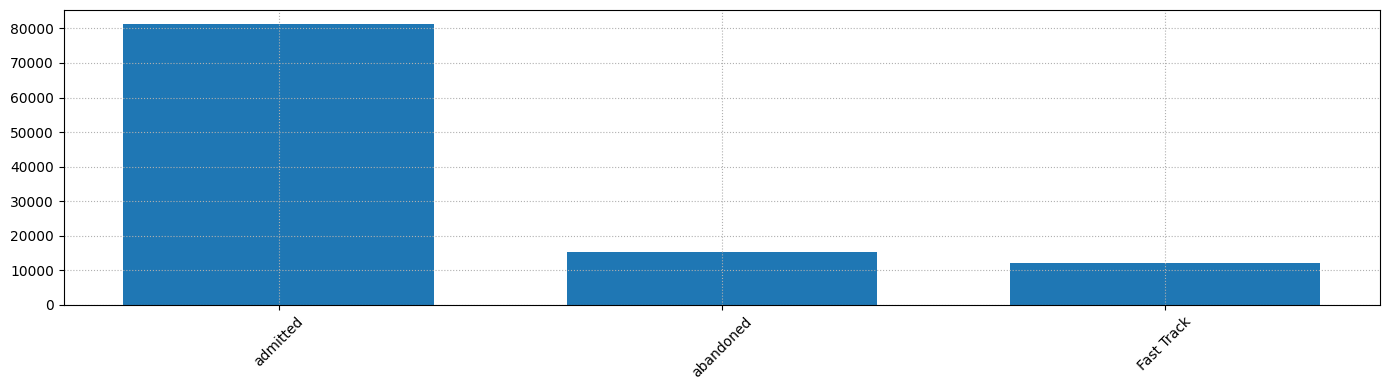

In [9]:
util.plot_bars(data['Outcome'].value_counts(), figsize=figsize)

* Abandons are infrequent, as are "fast track" patients

## Arrival Distribution over Months

**Let's look at the arrival distribution over months**

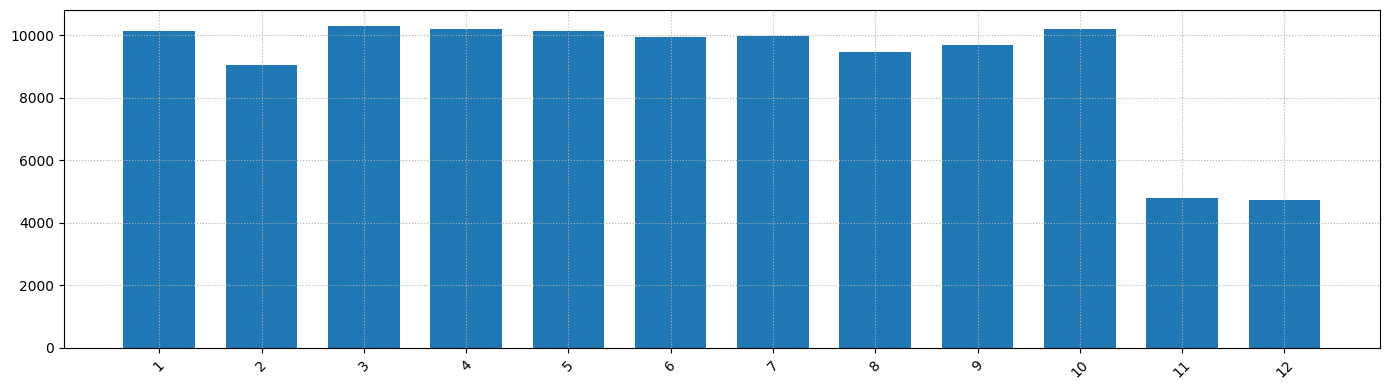

In [10]:
months = data['Triage'].dt.month
util.plot_bars(months.value_counts().sort_index(), figsize=figsize)

* The low values for Nov. and Dec. are due to the 2019 series ending in October
* The distribution seems stable (but we are not plotting standard deviations!).

## Arrival Distribution over Weekdays

**Let's look at the distribution over weekdays**

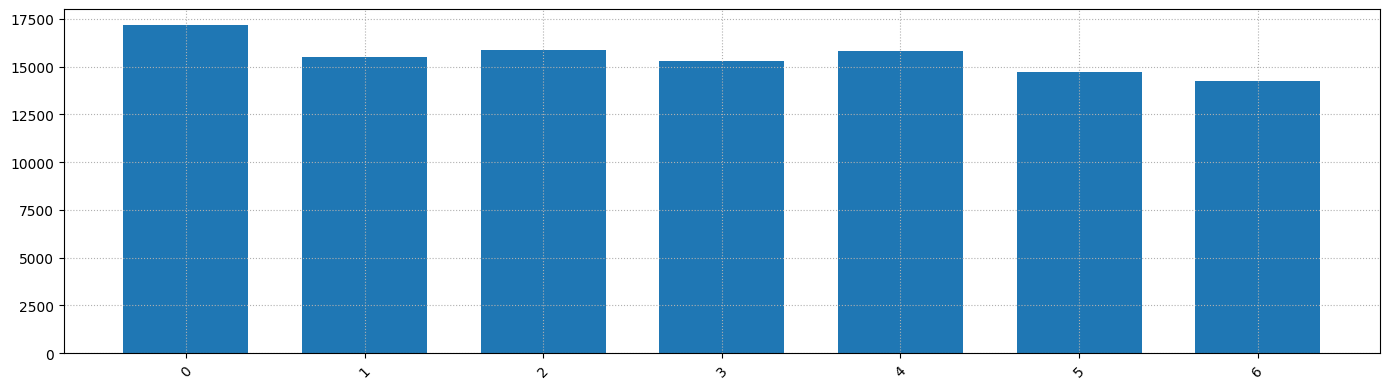

In [11]:
weekdays = data['Triage'].dt.weekday
util.plot_bars(weekdays.value_counts().sort_index(), figsize=figsize)

* Similarly to months, weekdays are likelly to have little predictive power
* ...But it's better not to rush conclusions (we still are not plotting the stddev!)

## Arrival Distribution over Hours

**Let's see now the arrival distribution over the hours of the day**

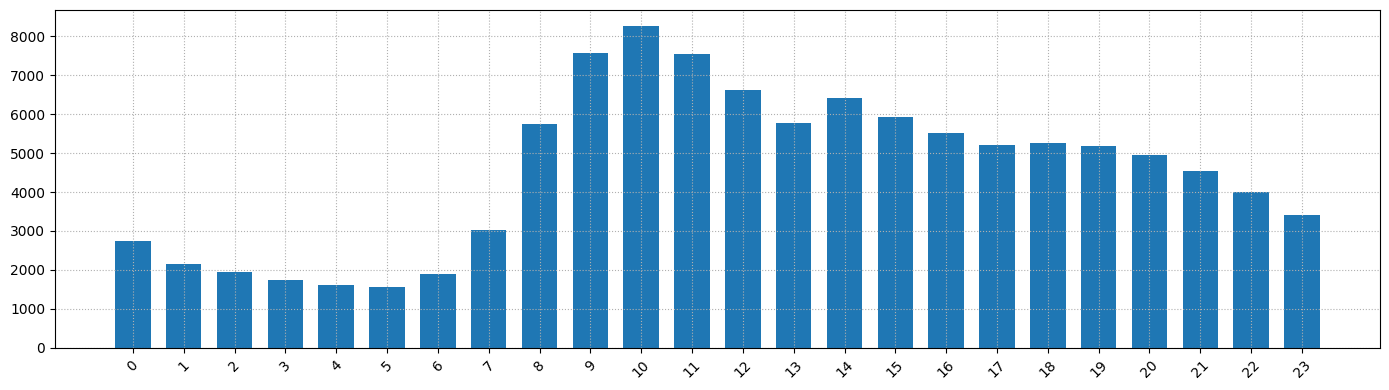

In [12]:
hours = data['Triage'].dt.hour
util.plot_bars(hours.value_counts().sort_index(), figsize=figsize)

* There is _a clear pattern_: the hour of the day will have strong predictive power
* Again, analyzing the standard deviation may provide better insights

# Data Preparation

## Binning

**In our considered problem:**

* We are not going to revise our decisions continuosly
* We are not interested in predicting the next arrival

Rather:

* We will take decisions _at fixed intervals_
* We care about the expected arrivals _in a given horizon_

**Overall, we need to choose _a meaningful time unit_**

In other words, we need to perform some kind of binning

* We used binning to downsample high-frequency data
* Here we will use binning to _aggregate events with a variable frequency_

## Code-Based Counts

**We will prepare the data to track counts for _all priority codes_**

In [ ]:
codes = pd.get_dummies(data['Code']) #get dummies creates a new dataframe where each unique value in the 'Code' column becomes a new column with binary values (0 or 1) indicating the presence of that code for each row.
codes.set_index(data['Triage'], inplace=True)
codes.columns = codes.columns.to_list()
print(f'Number of examples: {len(codes)}')
codes.head()

Number of examples: 108625


,green,red,white,yellow
Triage,,,,
2018-01-01 00:17:33,True,False,False,False
2018-01-01 00:20:33,True,False,False,False
2018-01-01 00:47:59,False,False,True,False
2018-01-01 00:49:51,False,False,True,False
2018-01-01 01:00:40,True,False,False,False


* The `get_dummies` function applies a one-hot encoding to categorical value
* The method generates a categorial column index (then converted to list)

## Resampling

**Then, we need to aggregate data with a specified frequency**

In [ ]:
codes_b = codes.resample('h').sum() #resample groups the data into hourly intervals and sum aggregates the values within each interval.
print(f'Number of examples: {len(codes_b)}')
codes_b.head()

Number of examples: 16056


,green,red,white,yellow
Triage,,,,
2018-01-01 00:00:00,2,0,2,0
2018-01-01 01:00:00,7,1,1,1
2018-01-01 02:00:00,4,1,4,3
2018-01-01 03:00:00,7,0,1,1
2018-01-01 04:00:00,3,0,2,0


* We used the `resample` iterator
* `resample` generater a dataframe with a _dense_ index
* We chose 1 hours are our time unit

## Computing Totals

**We also compute the total number of arrivals for each interval**

In [15]:
cols = ['white', 'green', 'yellow', 'red']
codes_b['total'] = codes_b[cols].sum(axis=1)
codes_b

,green,red,white,yellow,total
Triage,,,,,
2018-01-01 00:00:00,2,0,2,0,4
2018-01-01 01:00:00,7,1,1,1,10
2018-01-01 02:00:00,4,1,4,3,12
2018-01-01 03:00:00,7,0,1,1,9
2018-01-01 04:00:00,3,0,2,0,5
...,...,...,...,...,...
2019-10-31 19:00:00,3,1,0,4,8
2019-10-31 20:00:00,9,0,2,0,11
2019-10-31 21:00:00,3,0,0,2,5


* The total count will be less noisy, if the individual terms are independent

## Adding Time Information

**Finally, we add time information (for later convenience)**

In [ ]:
codes_bt = codes_b.copy()
codes_bt['month'] = codes_bt.index.month
codes_bt['weekday'] = codes_bt.index.weekday
codes_bt['hour'] = codes_bt.index.hour
codes_bt

#now we have a dataframe with dense index, columns for each triage code (and the total of triages) in that hour, and additional columns for month, weekday, and hour of the day.

,green,red,white,yellow,total,month,weekday,hour
Triage,,,,,,,,
2018-01-01 00:00:00,2,0,2,0,4,1,0,0
2018-01-01 01:00:00,7,1,1,1,10,1,0,1
2018-01-01 02:00:00,4,1,4,3,12,1,0,2
2018-01-01 03:00:00,7,0,1,1,9,1,0,3
2018-01-01 04:00:00,3,0,2,0,5,1,0,4
...,...,...,...,...,...,...,...,...
2019-10-31 19:00:00,3,1,0,4,8,10,3,19
2019-10-31 20:00:00,9,0,2,0,11,10,3,20
2019-10-31 21:00:00,3,0,0,2,5,10,3,21


## Counts over Time

**Our resampled series can be plotted easily over time**

Let's see the total counts as an example:

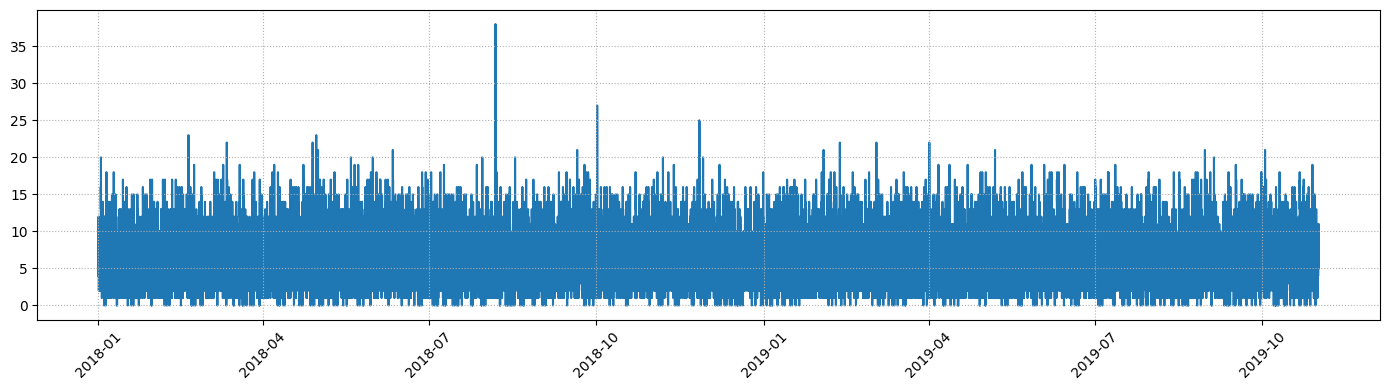

In [17]:
util.plot_series(codes_b['total'], figsize=figsize)

## Counts over Time

**Our resampled series can be plotted easily over time**

The same plot, for the red codes (the counts are significanly lower):

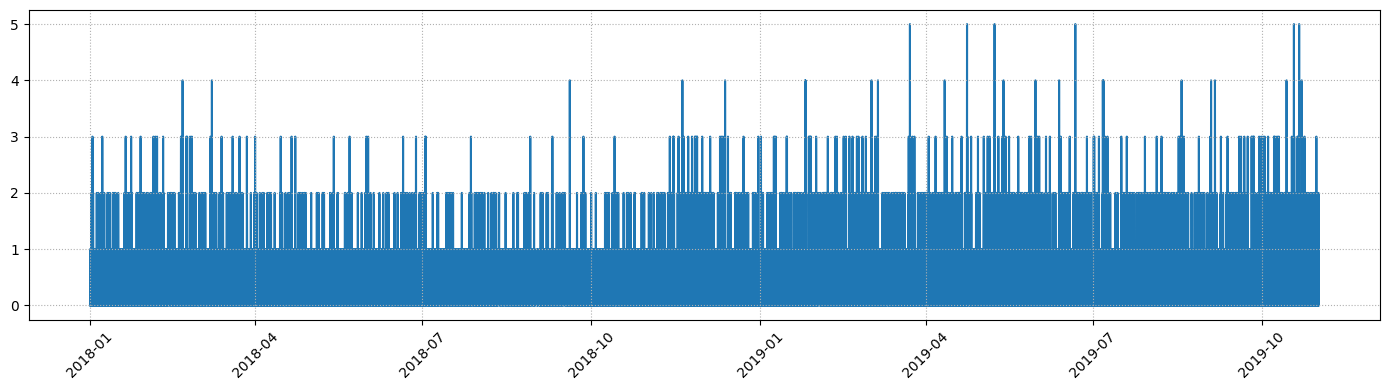

In [18]:
util.plot_series(codes_b['red'], figsize=figsize)

## Variability

**With our binned series, we can assess the count variability**

Let's check it over different months:

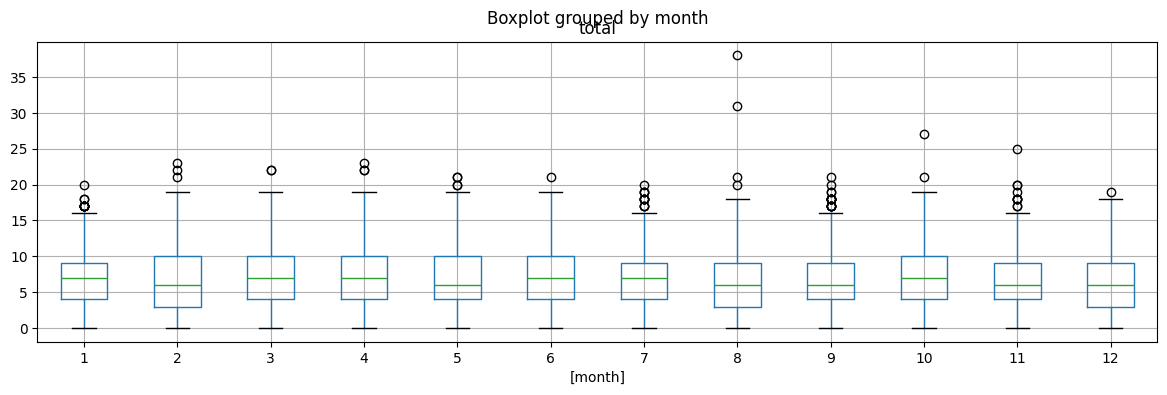

In [ ]:
codes_bt[['month', 'total']].boxplot(by='month', figsize=figsize);
#on the x axis we have the months (1 to 12) and on the y axis we have the distribution of total triages for each month.

* The variability does not change much over different months

## Variability

**Here is the standard deviation over weekdays**

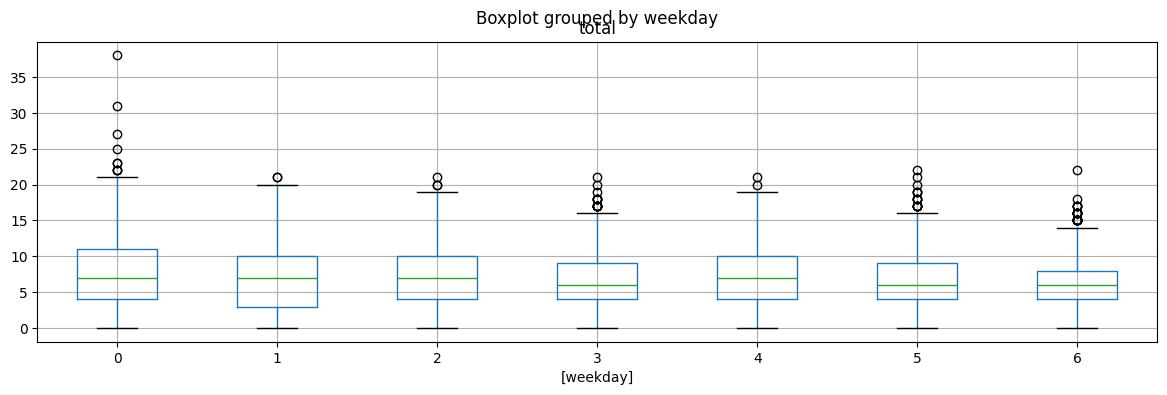

In [20]:
codes_bt[['weekday', 'total']].boxplot(by='weekday', figsize=figsize);

* There is a trend, but rather weak

## Variability

**...And finally over hours**

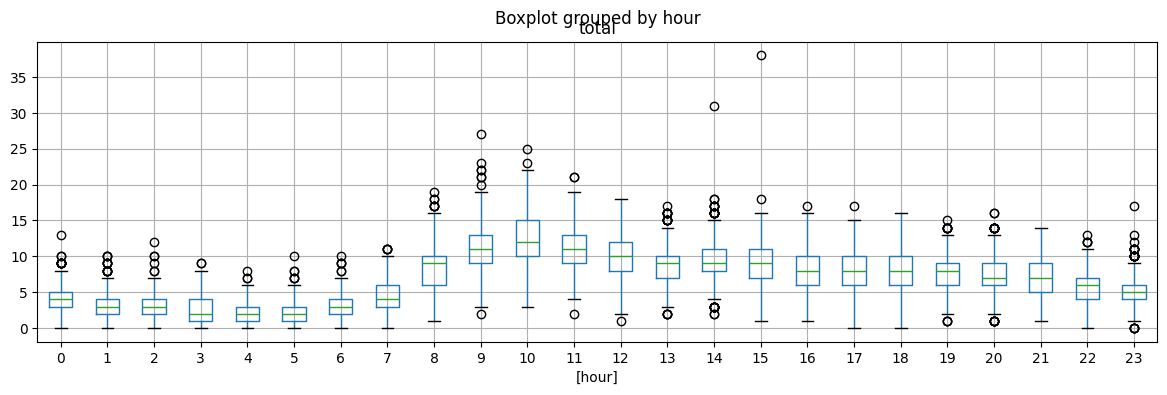

In [21]:
codes_bt[['hour', 'total']].boxplot(by='hour', figsize=figsize);

* Variance and mean seem to be quite correlated